# Module 3 – CNN (Car Damage Detection)

## Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")

Libraries imported successfully!


## Define Dataset Paths

In [2]:
train_dir = r"D:\InsureAI\data\Damage\data1a\training"
valid_dir = r"D:\InsureAI\data\Damage\data1a\validation"

print("Training Folder :", train_dir)
print("Validation Folder:", valid_dir)

Training Folder : D:\InsureAI\data\Damage\data1a\training
Validation Folder: D:\InsureAI\data\Damage\data1a\validation


## Image Preprocessing and Data Augmentation

In [3]:
# Training Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.0
)

# Validation Data Generator
valid_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image preprocessing and data augmentation completed successfully!")

Image preprocessing and data augmentation completed successfully!


## Load Training and Validation Images

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass Indices:")
print(train_generator.class_indices)

Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.

Class Indices:
{'00-damage': 0, '01-whole': 1}


## Build CNN Model (From Scratch)

In [5]:
cnn_model = tf.keras.Sequential([

    # First Convolution Layer
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Layer
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Dropout
    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )

])

print("CNN Model Created Successfully!")

d:\InsureAI\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


## CNN Model Summary

In [6]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile CNN Model

In [7]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


## Train CNN Model

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5451 - loss: 0.7795 - val_accuracy: 0.5761 - val_loss: 0.6624
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 53s 915ms/step - accuracy: 0.6239 - loss: 0.6423 - val_accuracy: 0.7022 - val_loss: 0.6018
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 53s 909ms/step - accuracy: 0.6658 - loss: 0.6200 - val_accuracy: 0.6674 - val_loss: 0.5967
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 52s 891ms/step - accuracy: 0.7033 - loss: 0.5802 - val_accuracy: 0.7087 - val_loss: 0.5275
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 936ms/step - accuracy: 0.7217 - loss: 0.5552 - val_accuracy: 0.7152 - val_loss: 0.5412
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 57s 976ms/step - accuracy: 0.7201 - loss: 0.5453 - val_accuracy: 0.7413 - val_loss: 0.5371
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 57s 973ms/step - accuracy: 0.7196 - loss: 0.5417 - val_accuracy: 0.7196 - val_loss: 0.5169
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 56s 964ms/step - accuracy: 0.7446 - loss: 0.5314 - val_accurac

## CNN Model Evaluation

In [9]:
# Evaluate the model
test_loss, test_accuracy = cnn_model.evaluate(validation_generator)

print(f"\nValidation Loss    : {test_loss:.4f}")
print(f"Validation Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.8283 - loss: 0.3868

Validation Loss    : 0.3868
Validation Accuracy: 0.8283


## Training vs Validation Accuracy

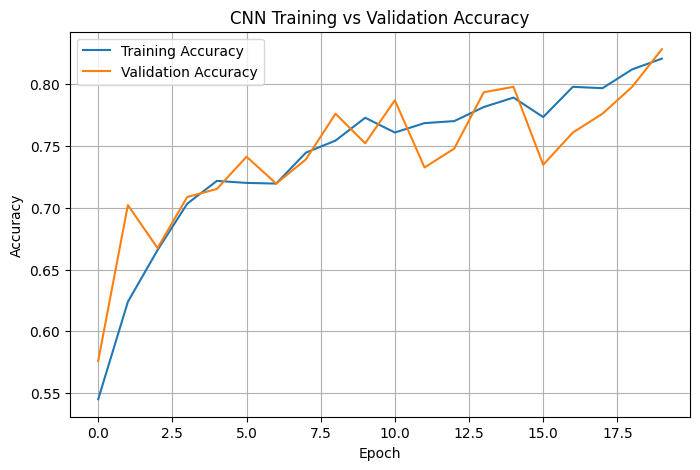

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Training vs Validation Loss

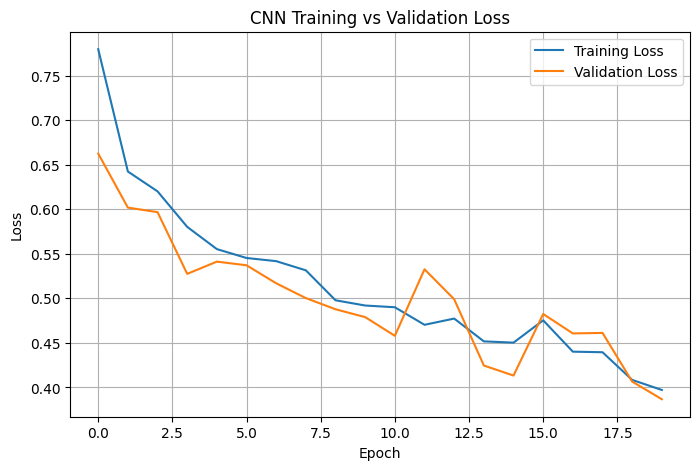

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Save CNN Model

In [12]:
cnn_model.save("../models/cnn_car_damage_detection.keras")

print("CNN model saved successfully!")

CNN model saved successfully!
